1.**⁠ ⁠NumPy Financial Calculator:** Build a compound interest calculator for savings plans; compute future values for rates between 5% and 25% using broadcasting; plot results.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class FinancialCalc:
    def __init__(self, principal, time):
        self.principal = principal
        self.time = time

    def compound_interest_future_value(self):
        # Rates from 5% to 25%
        rates = np.arange(0.05, 0.26, 0.05)   # [0.05, 0.10, 0.15, 0.20, 0.25]

        # Broadcasting calculation
        future_values = self.principal * (1 + rates) ** self.time

        return rates, future_values

    def display_results(self):
        rates, future_values = self.compound_interest_future_value()

        for rate, future_value in zip(rates, future_values):
            print(f"Future value at {rate*100:.0f}% interest: {future_value:.2f}")

    def plot_results(self):
        rates, future_values = self.compound_interest_future_value()

        plt.figure(figsize=(8, 5))
        plt.plot(rates * 100, future_values, marker='o')
        plt.xlabel("Interest Rate (%)")
        plt.ylabel("Future Value")
        plt.title("Compound Interest Future Value")
        plt.grid(True)
        plt.show()
        plt.pause(0.1)

Enter the principal amount: 5000
Enter the number of years you wish to save for: 1
Future value at 5% interest: 5250.00
Future value at 10% interest: 5500.00
Future value at 15% interest: 5750.00
Future value at 20% interest: 6000.00
Future value at 25% interest: 6250.00


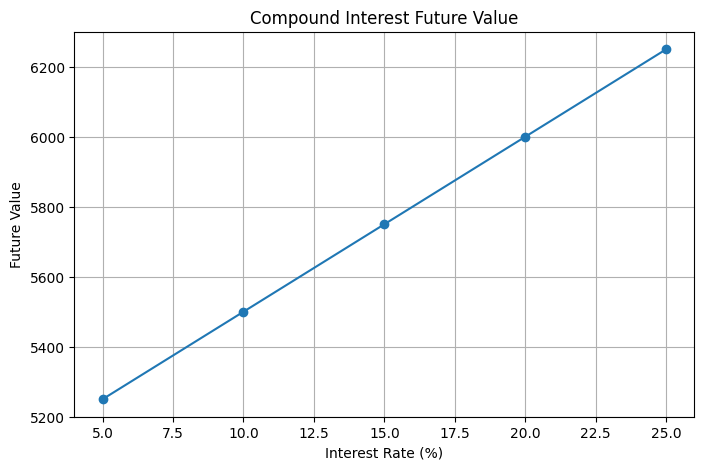

Do you wish to calculate for another principal amount? (y/n): n


In [ ]:
is_running = True
while is_running:
  #Step1: Ask user for inputs to calculation
  principal = float(input("Enter the principal amount: "))
  time = int(input("Enter the number of years you wish to save for: "))

  #Step2: Calculating the future values and displaying the results and plot
  calculation = FinancialCalc(principal, time)
  calculation.display_results()
  calculation.plot_results()

  #Step3: Ask user whether to continue computing or not
  user_input = input("Do you wish to calculate for another principal amount? (y/n): ")
  if user_input.lower() != 'y':
    is_running = False

2.⁠ **⁠Lagos Bus Data Parser:** Parse a JSON file with BRT (Bus Rapid Transit) route data; extract all routes serving Lagos; build a frequency table of peak-hour services using Pandas groupby; visualize with matplotlib. (Dataset: https://www.kaggle.com/datasets/issamoxix/data-json)


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
#Loading the JSON file
with open("qiit.Buses.json", "r", encoding="utf-8") as f:
    data = json.load(f)
    result_data=data[0].get("result")
    data_frame=pd.DataFrame(result_data)

data_frame.sample(10)


,provider,price,from,to,departure_time,departure_date,currency,id,return_flight,dep_terminal,dest_terminal,logo,booking_url,route_name
155,gigm,46700,lagos,abuja,06:00:00,2024-12-05T00:00:00,₦,4628,False,Lagos (Cele),FCT Abuja (Utako),https://res.cloudinary.com/dhkwjizxu/image/upl...,https://gigm.com/select-bus,Lagos (Cele) ==> FCT Abuja (Utako)
19,Pmt,28500,lagos,abuja,05:00,2024-12-05,₦,674e3c18d14f91a81bc774d5,False,"Lagos, Demorose","Abuja, Utako",https://res.cloudinary.com/dhkwjizxu/image/upl...,https://pmt.ng/travel/search?terminalFrom=5c51...,NaN
0,chisco,14250,lagos,abuja,7:15 AM,2024-12-05T00:00:00,₦,6d298357-f30a-4c58-4d9b-08dcdd6ea9e3,False,Meiran,Utako----pm,https://res.cloudinary.com/dhkwjizxu/image/upl...,https://chiscotransport.com.ng/bus-type,NaN
30,Pmt,28500,lagos,abuja,05:00,2024-12-05,₦,674e3c18d14f91a81bc77213,False,"Lagos, Mazamaza","Abuja, Utako",https://res.cloudinary.com/dhkwjizxu/image/upl...,https://pmt.ng/travel/search?terminalFrom=5c51...,NaN
78,Pmt,30000,lagos,abuja,05:00,2024-12-05,₦,674e3c18d14f91a81bc775d2,False,"Lagos, Jibowu","Abuja, Mararaba",https://res.cloudinary.com/dhkwjizxu/image/upl...,https://pmt.ng/travel/search?terminalFrom=5c51...,NaN
117,Pmt,31500,lagos,abuja,05:00,2024-12-05,₦,674e3c18d14f91a81bc77366,False,"Lagos, Ikorodu","Abuja, Mararaba",https://res.cloudinary.com/dhkwjizxu/image/upl...,https://pmt.ng/travel/search?terminalFrom=647e...,NaN
32,Pmt,28500,lagos,abuja,05:00,2024-12-05,₦,674e3c18d14f91a81bc77213,False,"Lagos, Mazamaza","Abuja, Utako",https://res.cloudinary.com/dhkwjizxu/image/upl...,https://pmt.ng/travel/search?terminalFrom=5c51...,NaN
150,abc,38200,NaN,NaN,06:15 AM,2024-12-05T00:00:00,₦,593123,False,Lagos Ajah,Abuja Bus Terminal,https://res.cloudinary.com/dhkwjizxu/image/upl...,https://www.abctransport.com/search-results,NaN
158,gigm,47000,lagos,abuja,06:00:00,2024-12-05T00:00:00,₦,32,False,Lagos(Jibowu),FCT Abuja(Utako),https://res.cloudinary.com/dhkwjizxu/image/upl...,https://gigm.com/select-bus,Lagos(Jibowu) ==> FCT Abuja(Utako)
46,Pmt,29500,lagos,abuja,05:00,2024-12-05,₦,674e3c18d14f91a81bc772f1,False,"Lagos, Ojuelegba","Abuja, Utako",https://res.cloudinary.com/dhkwjizxu/image/upl...,https://pmt.ng/travel/search?terminalFrom=5c51...,NaN


In [ ]:
#Filterng all routes involving lagos
Lagos_data =data_frame.copy()

#Creating a new column in the data frame for the routes
Lagos_data["route"]=Lagos_data["dep_terminal"]+ "->" +Lagos_data["dest_terminal"]

#replace suffixes (like pm and am)  in the route column
Lagos_data['route']=Lagos_data['route'].str.replace(r'-+[apAP][mM]','',regex=True)

#Printing routes
print(Lagos_data["route"].dropna().unique())

['Meiran->Utako' 'Jibowu->Utako' 'Empire->Utako'
 'Lagos, Jibowu->Abuja, Utako' 'Lagos, Demorose->Abuja, Utako'
 'Lagos, Mazamaza->Abuja, Utako' 'Lagos, Ojuelegba->Abuja, Utako'
 'Jibowu Bus Terminal->Abuja Bus Terminal'
 'Lagos, Demorose->Abuja, Mararaba' 'Lagos, Mazamaza->Abuja, Mararaba'
 'Lagos, Jibowu->Abuja, Mararaba' 'Lagos, Ojuelegba->Abuja, Mararaba'
 'Lagos, Ikorodu->Abuja, Utako' 'Lagos, Ikorodu->Abuja, Mararaba'
 'Lagos, Ajah->Abuja, Mararaba' 'Lagos, Ajah->Abuja, Utako'
 'Alafia 2->Utako' 'Lagos Ajah->Abuja Bus Terminal'
 'Lagos (Jibowu)->FCT Abuja (Mararaba)' 'Lagos (Ajah)->FCT Abuja (Utako)'
 'Lagos (Festac (mazamaza))->FCT Abuja (Utako)'
 'Lagos (Cele)->FCT Abuja (Utako)' 'Lagos (Ikotun)->FCT Abuja (Utako)'
 'Lagos(Jibowu)->FCT Abuja(Utako)'
 'Lagos (Iyana Ipaja)->FCT Abuja (Utako)']


In [32]:
#Converting departure_time to datetime
Lagos_data["parsed_departure_time"] = pd.to_datetime(Lagos_data["departure_time"],errors="coerce")

#Extracting the hour from the datetime
Lagos_data['hour']=Lagos_data['parsed_departure_time'].dt.hour

# Printing the count of NaN values in the 'hour' column
print(Lagos_data['hour'].isna().sum())
print(f"Hour range: {Lagos_data['hour'].min()} - {Lagos_data['hour'].max()}")

0
Hour range: 5 - 19


/tmp/ipykernel_23448/1645322068.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Lagos_data["parsed_departure_time"] = pd.to_datetime(Lagos_data["departure_time"],errors="coerce")


In [34]:
#Create a frequency table to establish peak hours
freq_table=Lagos_data.groupby("hour").size().reset_index(name="frequency")

#Changing the 24 hours format to 12 hours am/pm format
freq_table["hour"]=freq_table["hour"].apply(lambda x:f"{x} AM" if x<12 else f"12 PM" if x==12 else f"{x-12} PM")
print(freq_table)

   hour  frequency
0  5 AM        146
1  6 AM          9
2  7 AM          2
3  5 PM          2
4  7 PM          1


Text(0, 0.5, 'Number of Departure Buses')

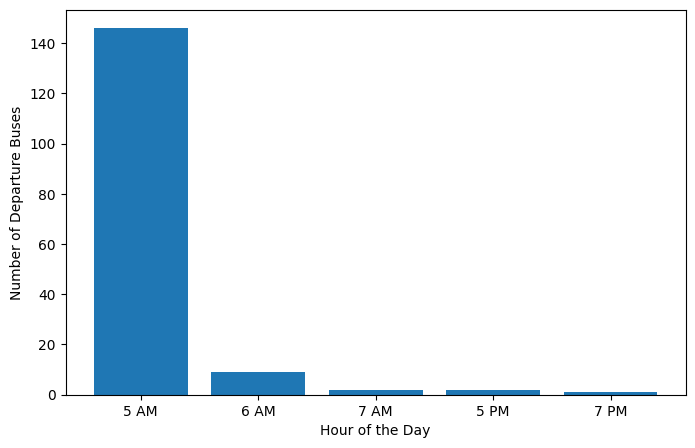

In [36]:
#Visualizing peak hour with matplotlib
plt.figure(figsize=(8,5))
plt.bar(freq_table["hour"],freq_table["frequency"])
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Departure Buses")